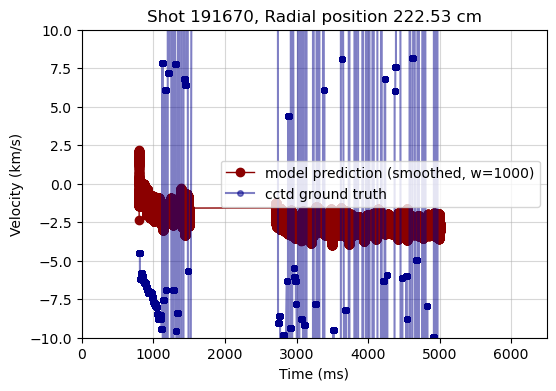

Saved plot for shot 191670 @ rpos 222.533 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_222.533.png


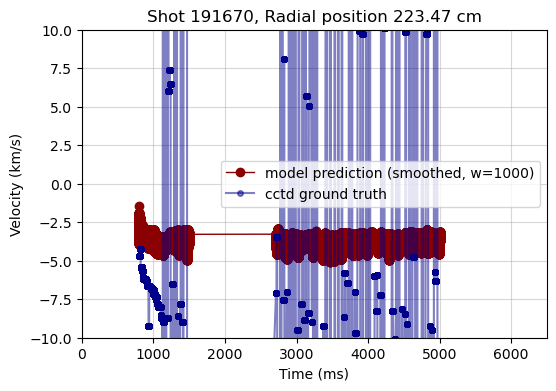

Saved plot for shot 191670 @ rpos 223.474 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_223.474.png


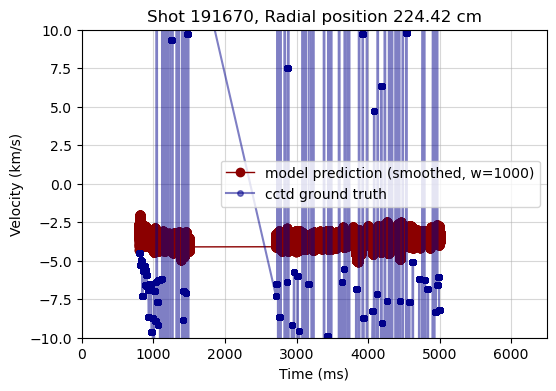

Saved plot for shot 191670 @ rpos 224.418 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_224.418.png


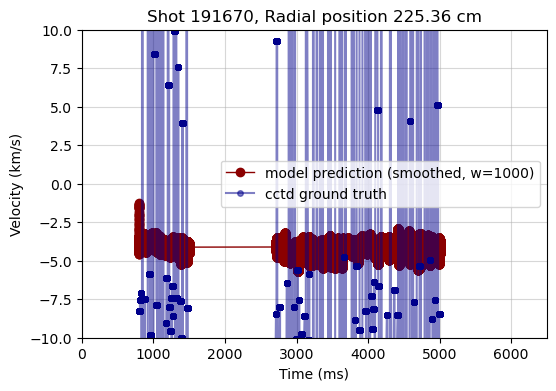

Saved plot for shot 191670 @ rpos 225.362 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_225.362.png


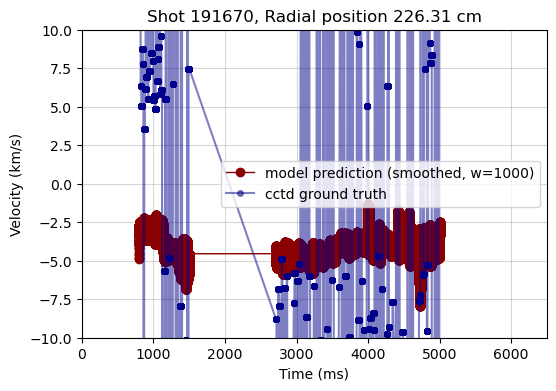

Saved plot for shot 191670 @ rpos 226.314 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_226.314.png


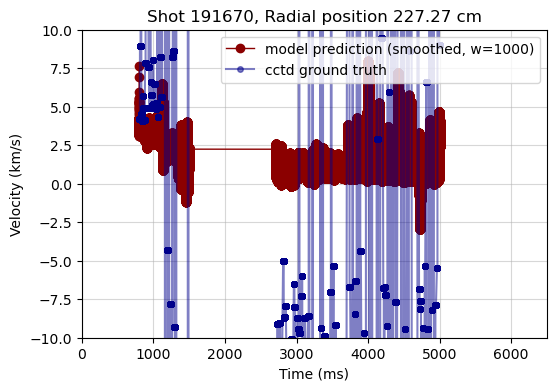

Saved plot for shot 191670 @ rpos 227.268 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_227.268.png


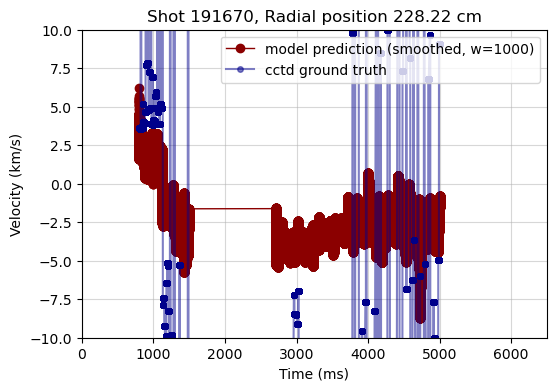

Saved plot for shot 191670 @ rpos 228.224 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191670_rpos_228.224.png


/global/common/software/nersc9/pytorch/2.3.1/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


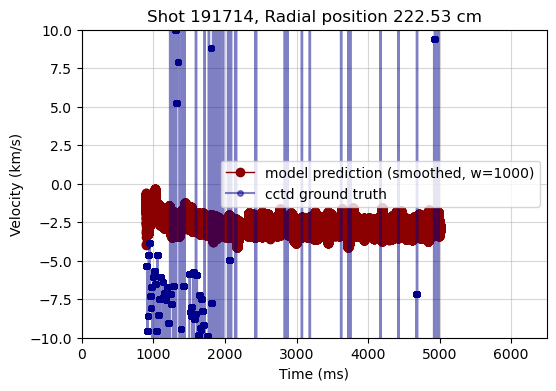

Saved plot for shot 191714 @ rpos 222.533 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_222.533.png


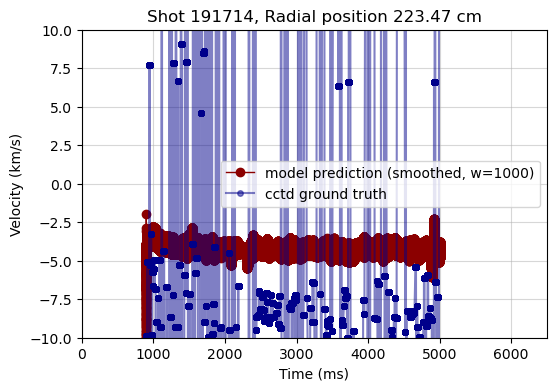

Saved plot for shot 191714 @ rpos 223.474 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_223.474.png


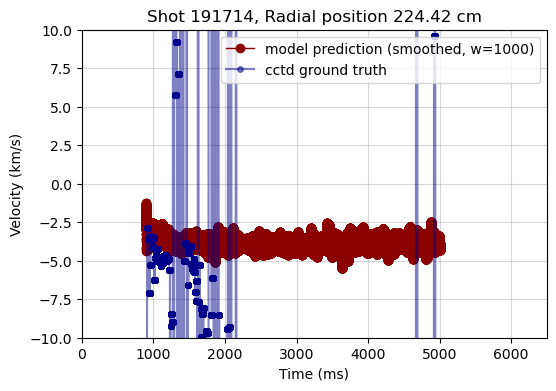

Saved plot for shot 191714 @ rpos 224.418 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_224.418.png


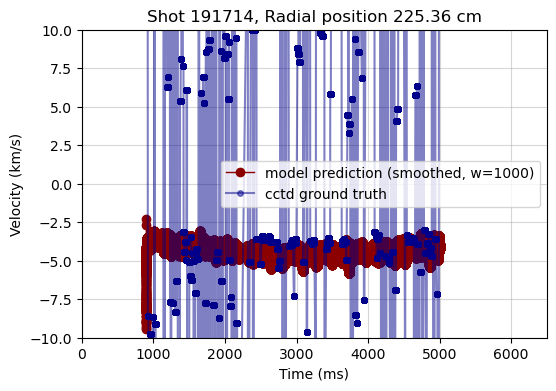

Saved plot for shot 191714 @ rpos 225.362 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_225.362.png


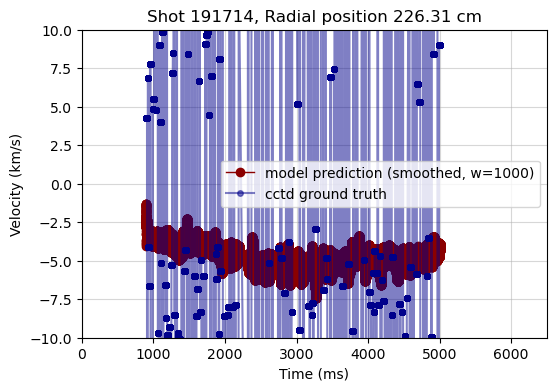

Saved plot for shot 191714 @ rpos 226.314 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_226.314.png


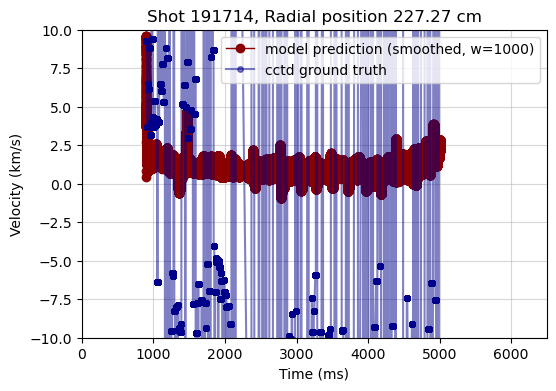

Saved plot for shot 191714 @ rpos 227.268 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_227.268.png


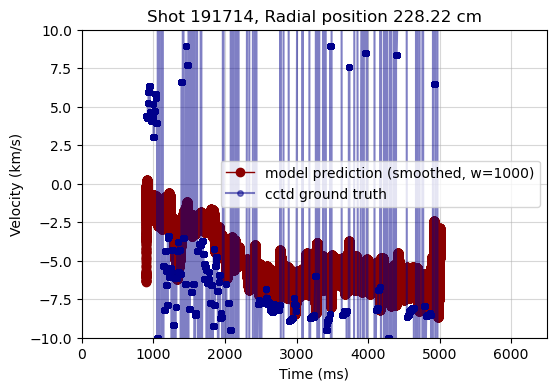

Saved plot for shot 191714 @ rpos 228.224 -> /pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots/shot_191714_rpos_228.224.png


In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

def backward_rolling_average(signal: np.ndarray, window_size: int = 5) -> np.ndarray:
    if window_size <= 1 or window_size > len(signal):
        return signal.copy()

    smoothed = np.zeros_like(signal)
    current_sum = 0.0
    start_idx = 0

    for i in range(len(signal)):
        current_sum += signal[i]
        # Drop values that move out of the window
        if i - window_size >= 0:
            current_sum -= signal[i - window_size]
            start_idx += 1
        count = i - start_idx + 1
        smoothed[i] = current_sum / count

    return smoothed

def plot_predictions_vs_truth(hdf5_file: str, output_dir: str = "plots", window_size: int = 5):
    """
    Reads an HDF5 file containing shot-level predictions, times, and radial positions.
    Creates time-series plots of predictions vs. true labels for each shot and radial position.
    
    Args:
        hdf5_file: Path to the predictions.hdf5 file produced by your LightningModule.
        output_dir: Directory where the plots will be saved.
    """
    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    with h5py.File(hdf5_file, 'r') as f:
        # Each shot is stored as a top-level group in HDF5
        shot_ids = list(f.keys())  # e.g. ["191670", "199718", ...]

        for shot_id in shot_ids:
            group = f[shot_id]
            
            # Load each dataset into memory
            predictions = group["predictions"][()]        # shape: (N,)
            true_labels = group["true_labels"][()]        # shape: (N,)
            times       = group["times"][()]              # shape: (N,)
            r_positions = group["radial_positions"][()]   # shape: (N,)

            # You can either:
            # (A) Plot *all* radial positions on one figure
            # or
            # (B) Split the data by radial position, producing one figure per radial position.
            #
            # Below is an example of strategy (B), 
            # but feel free to adapt as needed.

            unique_rpos = np.unique(r_positions)
            for rpos in unique_rpos:
                # Create a mask for this radial position
                rp_mask  = (r_positions == rpos)

                # Subset each array
                rp_times = times[rp_mask]
                rp_preds = predictions[rp_mask]
                rp_trues = true_labels[rp_mask]

                # Sort by time so the plot does not look scrambled
                sort_idx = np.argsort(rp_times)
                rp_times = rp_times[sort_idx]
                rp_preds = rp_preds[sort_idx]
                rp_trues = rp_trues[sort_idx]

                # Apply a backward rolling average to smooth predictions
                rp_preds_smoothed = backward_rolling_average(rp_preds, window_size=window_size)

                # Plot
                plt.figure(figsize=(6, 4))
                # plt.plot(rp_times, rp_preds, color='red', marker='o', label="model prediction", lw=2, alpha=0.4)
                plt.plot(rp_times, rp_preds_smoothed, color='darkred', marker='o', label=f"model prediction (smoothed, w={window_size})", lw=1)
                plt.plot(rp_times, rp_trues, color='darkblue', marker='o', label="cctd ground truth", markersize=4, alpha=0.5)
                plt.xlabel("Time (ms)")
                plt.ylabel("Velocity (km/s)")
                plt.title(f"Shot {shot_id}, Radial position {rpos:.2f} cm")
                plt.legend()
                plt.ylim(-10, 10)
                plt.xlim(0, 6500)
                plt.grid(True, alpha=0.5)

                # Save
                out_file = os.path.join(
                    output_dir, 
                    f"shot_{shot_id}_rpos_{rpos:.3f}.png"
                )
                # plt.savefig(out_file, dpi=150, bbox_inches="tight")
                # plt.close()
                plt.show()
                # print(f"Saved plot for shot {shot_id} @ rpos {rpos:.3f} -> {out_file}")


# Example usage:
hdf5_path = "/pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/predictions.hdf5"
hdf5_path = "/pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/34849261_on_191714_191670.hdf5"
output_dir = "/pscratch/sd/k/kevinsg/bes_ml_jobs/exp_gill01/34849261_copy/plots"

plot_predictions_vs_truth(hdf5_path, output_dir, 1000)
